In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
TAR_PATH = "/content/drive/MyDrive/ads/user_posts.tar.gz"
print(os.path.exists(TAR_PATH))

True


Sample 100k posts from the tar file

In [ ]:
import tarfile
import json
import time
import pandas as pd

save_path = "/content/drive/MyDrive/ads/posts_sample.csv"
sample_size = 100_000

records = []
t0 = time.time()

with tarfile.open(TAR_PATH, "r|gz") as tar:
    for member in tar:
        if len(records) >= sample_size:
            break
        if not member.name.endswith(".jsonl"):
            continue

        f = tar.extractfile(member)
        if f is None:
            continue

        for line in f:
            try:
                post = json.loads(line)
                langs = post.get("langs")

                if langs and "eng" not in langs:
                    break

                text = post.get("text")
                if not text or not str(text).strip():
                    continue

                records.append({
                    "post_id": post.get("post_id"),
                    "user_id": post.get("user_id"),
                    "text": text,
                    "date": post.get("date"),
                    "like_count": post.get("like_count", 0),
                    "reply_count": post.get("reply_count", 0),
                    "repost_count": post.get("repost_count", 0),
                    "is_reply": post.get("reply_to") is not None,
                    "is_repost": post.get("repost_from") is not None,
                    "is_quote": post.get("quotes") is not None,
                    "sent_label": post.get("sent_label"),
                    "sent_score": post.get("sent_score"),
                })

                break  # one post per user file

            except json.JSONDecodeError:
                continue

print(f"Fetched {len(records)} posts in {time.time() - t0}s")

df = pd.DataFrame(records)
df["timestamp"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d%H%M", errors="coerce")
df["text_length"] = df["text"].astype(str).str.len() # Making sure that the type is str to stop errors

df.to_csv(save_path, index=False)
print(f"Saved to {save_path}")
df.head()

Fetched 100000 posts in 68.97593307495117s
Saved to /content/drive/MyDrive/ads/posts_sample.csv


,post_id,user_id,text,date,like_count,reply_count,repost_count,is_reply,is_repost,is_quote,sent_label,sent_score,timestamp,text_length
0,185310360,1028680,bitcoin spiking just before christmas... i'm r...,202312060142,23,0,3,False,True,False,1.0,0.493,2023-12-06 01:42:00,168
1,91191477,265900,Started off #WRAD today with Ms. Drew & her 3r...,202402051549,3,0,0,False,False,False,2.0,0.982,2024-02-05 15:49:00,175
2,65435247,1535259,He always words these tweets so that he can al...,202403170404,76,1,1,True,False,False,0.0,0.743,2024-03-17 04:04:00,152
3,219348625,706124,seen in washington sq park,202403181425,1279,30,209,False,True,False,1.0,0.901,2024-03-18 14:25:00,26
4,221949969,558873,i'm convinced that academic book reviews prima...,202403141636,0,0,0,False,False,False,0.0,0.699,2024-03-14 16:36:00,107


Sample 500 posts from the 100k sample and use that for manual ground truth annotation (gold standard)

In [ ]:
df = pd.read_csv(save_path)

df["combined_engagement"] = df["like_count"].fillna(0) + df["repost_count"].fillna(0)
threshold = df["combined_engagement"].quantile(0.9)
df["is_viral"] = (df["combined_engagement"] > threshold).astype(int)

candidates = df[
    (df["text_length"] > 30) &
    (df["combined_engagement"] > 0)
].copy()

gt_sample = candidates.sample(500, random_state=42).copy()

gt_sample["is_claim_manual"] = "" # yes/no
gt_sample["veracity_manual"] = "" # misinformation/not_misinformation/unsure/null

gt_path = "/content/drive/MyDrive/ads/gt_sample_misinfo.csv"
gt_sample.to_csv(gt_path, index=False)

print(f"Saved {len(gt_sample):,} rows to {gt_path}")
print(f"Viral in sample: {gt_sample['is_viral'].sum()} ({gt_sample['is_viral'].mean()*100:.1f}%)")
gt_sample.head()

Saved 500 rows to /content/drive/MyDrive/ads/gt_sample_misinfo.csv
Viral in sample: 76 (15.2%)


,post_id,user_id,text,date,like_count,reply_count,repost_count,is_reply,is_repost,is_quote,sent_label,sent_score,timestamp,text_length,combined_engagement,is_viral,is_claim_manual,veracity_manual
56207,142273704,2772327,Gotta join here too to up my chances!,202311080024,1,0,0,True,False,False,2.0,0.656,2023-11-08 00:24:00,37,1,0,,
5029,147919256,3481704,Half a million people in London right now. Jew...,202310281551,5344,72,1880,False,True,False,2.0,0.542,2023-10-28 15:51:00,265,7224,1,,
55440,209559306,2487344,"wangxian a/b/o\n\ncw: bitching\n\nokay, we tal...",202310200236,56,117,25,False,True,False,0.0,0.519,2023-10-20 02:36:00,288,81,0,,
19425,65045065,2180879,Estreando essa rede social nova e ja me prepar...,202308310227,7,0,0,False,False,False,1.0,0.860,2023-08-31 02:27:00,82,7,0,,
82994,63345492,119050,Similar image I found a way back.,202403181840,21,0,3,True,True,False,1.0,0.758,2024-03-18 18:40:00,33,24,0,,


After labelling the ground truth I got a split of 452 not_claim to 47 claims so I decided to look specifically at posts that likely claimed something, by searching for posts with a specific set of keywords. The original plan was to have a manual ground truth for benchmarking/evaluation but the number of claims (and hence misinfo/not_misinfo tags) would be too little to do any meaningful training or evaluation.

In [ ]:
import pandas as pd
import re

# paths
save_path = save_path = "/content/drive/MyDrive/ads/posts_sample.csv"
gt_path = "/content/drive/MyDrive/ads/gt_sample_misinfo.csv"

# keyword list
keywords = [
    'breaking', 'confirmed', 'study shows', 'according to',
    'percent', '%', 'million', 'billion', 'voted', 'announced',
    'scientists', 'research', 'report', 'data shows', 'first country',
    'ban', 'law', 'court', 'arrested', 'died', 'killed'
]

df = pd.read_csv(posts_path)
gt = pd.read_csv(gt_path)

# rebuild useful columns if needed
df["combined_engagement"] = df["like_count"].fillna(0) + df["repost_count"].fillna(0)
threshold = df["combined_engagement"].quantile(0.9)
df["is_viral"] = (df["combined_engagement"] > threshold).astype(int)

# keyword regex
pattern = "|".join(re.escape(k) for k in keywords)

# find extra claim-like candidates, excluding ones already in gt
claim_candidates = df[
    (df["text"].notna()) &
    (df["text_length"] > 30) &
    (df["combined_engagement"] > 0) &
    (~df["post_id"].isin(gt["post_id"])) &
    (df["text"].astype(str).str.contains(pattern, case=False, na=False, regex=True))
].copy()

print(f"Claim-like candidates found: {len(claim_candidates):,}")

# sample 400 more
n_extra = min(400, len(claim_candidates))
extra = claim_candidates.sample(n=n_extra, random_state=42).copy()

extra["is_claim_manual"] = ""
extra["veracity_manual"] = ""

# append and save
gt_augmented = pd.concat([gt, extra], ignore_index=True)
gt_augmented.to_csv(gt_path, index=False)

print(f"Added {n_extra} more rows")
print(f"New gt size: {len(gt_augmented):,}")
gt_augmented.head()

Claim-like candidates found: 3,631
Added 400 more rows
New gt size: 900


,post_id,user_id,text,date,like_count,reply_count,repost_count,is_reply,is_repost,is_quote,sent_label,sent_score,timestamp,text_length,combined_engagement,is_viral,is_claim_manual,veracity_manual
0,142273704,2772327,Gotta join here too to up my chances!,202311080024,1,0,0,True,False,False,2.0,0.656,2023-11-08 00:24:00,37,1,0,NaN,NaN
1,147919256,3481704,Half a million people in London right now. Jew...,202310281551,5344,72,1880,False,True,False,2.0,0.542,2023-10-28 15:51:00,265,7224,1,NaN,NaN
2,209559306,2487344,"wangxian a/b/o\n\ncw: bitching\n\nokay, we tal...",202310200236,56,117,25,False,True,False,0.0,0.519,2023-10-20 02:36:00,288,81,0,NaN,NaN
3,65045065,2180879,Estreando essa rede social nova e ja me prepar...,202308310227,7,0,0,False,False,False,1.0,0.860,2023-08-31 02:27:00,82,7,0,NaN,NaN
4,63345492,119050,Similar image I found a way back.,202403181840,21,0,3,True,True,False,1.0,0.758,2024-03-18 18:40:00,33,24,0,NaN,NaN


Didn't work either after adding a whole ass 400 posts too because even though I got a total of 173 claim posts from the 900 across both files (original 500 + 400 claim-likely posts), I labelled misinfo and even with borderline cases I couldnt come across more than 10 that could be verified as misinformation. The plan is to drop the gold standard and do evaluation against the ai-labelled weakly annotated ground truth

In [ ]:
!pip install openai -q

In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [ ]:
import asyncio
import json
import os
import re
from pathlib import Path

import pandas as pd
from openai import AsyncOpenAI
from tqdm.asyncio import tqdm_asyncio

import tarfile
import time

TAR_PATH    = "/content/drive/MyDrive/ads/user_posts.tar.gz"
OUTPUT_CSV  = "/content/drive/MyDrive/ads/weak_label_samples.csv"
SAMPLE_SIZE = 100_000

MODEL       = "gpt-4.1-mini"
CONCURRENCY = 8
RETRY_LIMIT = 6
RETRY_DELAY = 15.0

VALID_IS_CLAIM = {"yes", "no"}
VALID_VERACITY = {"misinformation", "not_misinformation", "unsure", None}

SYSTEM = """\
You are an expert weak annotator for misinformation research on social media posts.

TASK 1 — CLAIM DETECTION
A post contains a claim if it makes a declarative, verifiable factual assertion about the world.
Opinions, emotions, jokes,
vague speculation, slogans, and pure reactions are NOT claims.

TASK 2 — VERACITY (ONLY if TASK 1 = yes)
Classify as one of:

- misinformation: the post states or clearly endorses a claim that is false or materially misleading. Materially misleading includes major missing context, deceptive framing, certainty inflation, over-generalisation, or causal overclaiming that leaves a false impression.

- not_misinformation: the claim appears accurate or is not contradicted by available evidence.

- unsure: the claim exists but truth status is too unclear or
contextual to assess confidently from the text alone.

IMPORTANT:
- Rhetorical style (sensationalism, urgency, pseudo-authority) is a supporting signal only.
A post can be emotional and still be not_misinformation. A post can be calm and still be misinformation
- A post can be a claim but still be unsure.
- If is_claim = no, veracity MUST BE null.

Return ONLY valid JSON. No explanation. No markdown. No extra text.
{"is_claim": "yes"|"no", "veracity": "misinformation"|"not_misinformation"|"unsure"|null, "confidence": 0.0}
"""

FEW_SHOTS = [
    (
        "The WHO declared COVID-19 a pandemic in March 2020.",
        {"is_claim": "yes", "veracity": "not_misinformation", "confidence": 0.95}
    ),
    (
        "Can't believe people still support this clown.",
        {"is_claim": "no", "veracity": None, "confidence": 0.96}
    ),
    (
        "Bill Gates has publicly confirmed that 5G towers were designed to track human movements and the data is sold to governments.",
        {"is_claim": "yes", "veracity": "misinformation", "confidence": 0.92}
    ),
    (
        "Measles infection causes immune amnesia, wiping out antibodies the body had built up against other diseases.",
        {"is_claim": "yes", "veracity": "not_misinformation", "confidence": 0.91}
    ),
    (
        "A peer-reviewed study found that mRNA vaccines permanently alter human DNA and have caused over 500,000 unreported deaths in the US alone.",
        {"is_claim": "yes", "veracity": "misinformation", "confidence": 0.93}
    ),
    (
        "They are hiding the truth about what is really in the water supply.",
        {"is_claim": "no", "veracity": None, "confidence": 0.91}
    ),
    (
        "BREAKING: France has become the first country in the world to explicitly enshrine abortion rights in its national constitution.",
        {"is_claim": "yes", "veracity": "not_misinformation", "confidence": 0.85}
    ),
    (
        "Studies show that 74% of people who work from home are more productive than those who work in an office.",
        {"is_claim": "yes", "veracity": "unsure", "confidence": 0.75}
    ),
    (
        "Albert Einstein failed mathematics at school and was considered a poor student by all of his teachers.",
        {"is_claim": "yes", "veracity": "misinformation", "confidence": 0.82}

    ),(
        "According to a recent government report, electric vehicles produce more carbon emissions over their lifetime than petrol cars.",
        {"is_claim": "yes", "veracity": "unsure", "confidence": 0.58}
    ),
]


def parse_response(raw: str) -> tuple[str, str | None, float]:
    clean = re.sub(r"```(?:json)?|```", "", raw).strip()
    try:
        obj = json.loads(clean)
        is_claim  = str(obj.get("is_claim", "")).lower().strip()
        veracity  = obj.get("veracity", None)
        if isinstance(veracity, str):
            veracity = veracity.lower().strip()
        confidence = float(obj.get("confidence", 0.0))
        if is_claim not in VALID_IS_CLAIM:
            is_claim = "no"
        if veracity not in VALID_VERACITY:
            veracity = None
        if is_claim == "no":
            veracity = None
        confidence = max(0.0, min(1.0, confidence))
        return is_claim, veracity, confidence
    except Exception:
        return "no", None, 0.0

def load_posts_from_tar(tar_path: str, sample_size: int) -> pd.DataFrame:
    records = []
    t0 = time.time()

    with tarfile.open(tar_path, "r|gz") as tar:
        for member in tar:
            if len(records) >= sample_size:
                break
            if not member.name.endswith(".jsonl"):
                continue

            f = tar.extractfile(member)
            if f is None:
                continue

            for line in f:
                try:
                    post = json.loads(line)
                    langs = post.get("langs")

                    if langs and "eng" not in langs:
                        break

                    text = post.get("text")
                    if not text or len(str(text).strip()) <= 30:
                        continue

                    engagement = post.get("like_count", 0) + post.get("repost_count", 0)
                    if engagement == 0:
                        continue

                    records.append({
                        "post_id": post.get("post_id"),
                        "user_id": post.get("user_id"),
                        "text": text,
                        "date": post.get("date"),
                        "like_count": post.get("like_count", 0),
                        "reply_count": post.get("reply_count", 0),
                        "repost_count": post.get("repost_count", 0),
                        "is_reply": post.get("reply_to") is not None,
                        "is_repost": post.get("repost_from") is not None,
                        "is_quote": post.get("quotes") is not None,
                        "sent_label": post.get("sent_label"),
                        "sent_score": post.get("sent_score"),
                    })

                    break

                except json.JSONDecodeError:
                    continue

    print(f"Fetched {len(records)} posts from tar in {time.time() - t0:.2f}s")

    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(
        df["date"].astype(str),
        format="%Y%m%d%H%M",
        errors="coerce"
    )
    df["text_length"] = df["text"].astype(str).str.len()
    df["combined_engagement"] = df["like_count"] + df["repost_count"]
    threshold = df["combined_engagement"].quantile(0.9)
    df["is_viral"] = (df["combined_engagement"] >= threshold).astype(int)
    print(f"Viral threshold: {threshold}, viral rate: {df['is_viral'].mean()*100:.1f}%")

    return df

async def label_post(
    client: AsyncOpenAI,
    sem: asyncio.Semaphore,
    idx: int,
    text: str,
) -> dict:
    async with sem:
        for attempt in range(RETRY_LIMIT):
            try:
                response = await client.chat.completions.create(
                    model=MODEL,
                    messages=[
                        {"role": "system", "content": SYSTEM},
                        *[msg for fs_text, label in FEW_SHOTS for msg in [
                            {"role": "user",      "content": f'Post: "{fs_text}"'},
                            {"role": "assistant", "content": json.dumps(label)},
                        ]],
                        {"role": "user", "content": f'Post: "{text}"'},
                    ],
                    temperature=0.1,
                    max_tokens=80,
                )
                raw = response.choices[0].message.content or ""
                is_claim, veracity, confidence = parse_response(raw)
                return {
                    "idx":               idx,
                    "is_claim":   is_claim,
                    "veracity":   veracity,
                    "confidence": confidence,
                }
            except Exception as e:
                err  = str(e).lower()
                wait = RETRY_DELAY * (3 ** attempt) if any(
                    x in err for x in ("429", "rate_limit", "quota")
                ) else RETRY_DELAY
                if attempt == RETRY_LIMIT - 1:
                    print(f"[WARN] idx={idx} failed after {RETRY_LIMIT} attempts: {e}")
                    return {
                        "idx":               idx,
                        "is_claim":   "no",
                        "veracity":   None,
                        "confidence": 0.0,
                    }
                await asyncio.sleep(wait)


async def main():
    output_path = Path(OUTPUT_CSV)

    df = load_posts_from_tar(TAR_PATH, SAMPLE_SIZE)
    df = df.sample(3000, random_state=42).reset_index(drop=True)
    if "text" not in df.columns:
        raise ValueError("Loaded data must contain a 'text' column")

    print(f"Loaded {len(df):,} rows from tar file")

    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key:
        raise EnvironmentError("Set OPENAI_API_KEY before running")

    client = AsyncOpenAI(api_key=api_key)
    sem    = asyncio.Semaphore(CONCURRENCY)

    if output_path.exists():
        done      = pd.read_csv(output_path, usecols=["idx"])["idx"].tolist()
        remaining = df[~df.index.isin(done)].copy()
        print(f"Resuming: {len(done):,} done, {len(remaining):,} remaining")
    else:
        remaining = df.copy()

    if remaining.empty:
        print("Nothing left to label.")
        return

    tasks   = [label_post(client, sem, idx, str(row["text"])) for idx, row in remaining.iterrows()]
    results = await tqdm_asyncio.gather(*tasks, desc="OpenAI weak labelling")

    results_df = pd.DataFrame(results).set_index("idx")

    for col in ["is_claim", "veracity", "confidence"]:
        if col not in df.columns:
            df[col] = None

    df.loc[results_df.index, "is_claim"]  = results_df["is_claim"]
    df.loc[results_df.index, "veracity"]   = results_df["veracity"]
    df.loc[results_df.index, "confidence"] = results_df["confidence"]

    df.to_csv(output_path, index=True, index_label="idx")
    print(f"\nSaved {len(df):,} rows → {output_path}")
    print("\nClaim distribution:")
    print(df["is_claim"].value_counts(dropna=False))
    print("\nVeracity distribution:")
    print(df["veracity"].value_counts(dropna=False))
    low_conf = (pd.to_numeric(df["confidence"], errors="coerce").fillna(0) < 0.7).sum()
    print(f"\nLow-confidence rows (<0.7): {low_conf:,}")


# In Jupyter / Colab:
await main()


Only 133 out of 3,000 posts are claims (4.4%) and of those only 9 are misinformation. That's a 56:9 ratio of not_misinformation to misinformation after dropping unsure. I can NOT train a meaningful binary classifier on like 9 positive examples. F1 on the misinformation class would do jack and my classifier will just predict not_misinfo for everything and still get an 86% accuracy its wraps. I could just add the "unsure" classifications to misinfo but then that wouldn't train the model in a meaninful way and lead to a very softened classification.

## The Pivot
- The Original Plan: Use the Google fact checking api and open ai api calls to check misinformation and label posts.

- Problem: A lot of posts were marked "unsure" since a lot of the info in them couldnt be verified by the database that the API used.

- Plan 2: Have a gold standard, manually annotated ground truth to mark posts as misinfo/not_misinfo/unsure and claim/not_claim and then using api calls to get a weakly annotated set to train 2 models (one that detects claims and one that detects misinfo) to be evaluated against the golden ground truth.

- Problem: Random sampling AND purposive sampling gave us data sets with few claims and even fewer posts that could conclusively be labelled as misinformation. This is not enough data to train or evaluate a model. "Unsure" posts could be labelled as misinfo to give use more labels but that wouldn't train the model to do any meaningful classification

- Plan 3: Forget the gold standard and just use ai for labelling so that we can get a good amount of claim-making, and hence, misinfo posts

- This sample also does not have enough posts that can be conclusively classified as misinfo to do any meaningful training/evaluation

- **Final Plan**: Make a model that checks if a post makes a claim or not so that we can explore the correlation between virality and claim-making posts

In [ ]:
import asyncio
import json
import os
import re
from pathlib import Path

import pandas as pd
from openai import AsyncOpenAI
from tqdm.asyncio import tqdm_asyncio

import tarfile
import time

TAR_PATH    = "/content/drive/MyDrive/ads/user_posts.tar.gz"
OUTPUT_CSV  = "/content/drive/MyDrive/ads/claim_weak_label_samples.csv"
SAMPLE_SIZE = 100_000

MODEL       = "gpt-4.1-mini"
CONCURRENCY = 8
RETRY_LIMIT = 6
RETRY_DELAY = 15.0

VALID_IS_CLAIM = {"yes", "no"}

SYSTEM = """\
You are an expert annotator for claim detection research on social media posts.

TASK — CLAIM DETECTION
Determine whether the post contains a verifiable factual claim.

A claim is a declarative statement about the world that is verifiable in principle
against evidence, records, or reliable reporting (Konstantinovskiy et al., 2021).

Label as "yes" if the post makes a specific, declarative, verifiable factual
assertion about an event, statistic, person's action, or state of the world.

Label as "no" if the post is an opinion, emotion, joke, question, vague
speculation, slogan, reaction, or contains no specific verifiable referent.

Return ONLY valid JSON. No explanation. No markdown. No extra text.
{"is_claim": "yes"|"no", "confidence": 0.0}
"""

FEW_SHOTS = [
    (
        "The WHO declared COVID-19 a pandemic in March 2020.",
        {"is_claim": "yes", "confidence": 0.95}
    ),
    (
        "Can't believe people still support this clown.",
        {"is_claim": "no", "confidence": 0.96}
    ),
    (
        "Bill Gates has publicly confirmed that 5G towers were designed "
        "to track human movements.",
        {"is_claim": "yes", "confidence": 0.93}
    ),
    (
        "They are hiding the truth about what is really in the water supply.",
        {"is_claim": "no", "confidence": 0.91}
    ),
    (
        "Measles infection causes immune amnesia, wiping out antibodies the body had built up against other diseases.",
        {"is_claim": "yes", "confidence": 0.91}
    ),
    (
        "BREAKING: France has become the first country in the world to explicitly enshrine abortion rights in its national constitution.",
        {"is_claim": "yes", "confidence": 0.88}
    ),
    (
        "Studies show that 74% of people who work from home are more productive than those who work in an office.",
        {"is_claim": "yes", "confidence": 0.82}
    ),
    (
        "Just had the best coffee of my life at this little place downtown.",
        {"is_claim": "no", "confidence": 0.95}
    ),
    (
        "The Alabama Supreme Court ruled that frozen embryos are unborn children and a valid wrongful death action can be based on their destruction.",
        {"is_claim": "yes", "confidence": 0.92}
    ),
    (
        "Why is nobody talking about what is happening in the food supply?",
        {"is_claim": "no", "confidence": 0.93}
    ),
]

def parse_response(raw: str) -> tuple[str, float]:
    clean = re.sub(r"```(?:json)?|```", "", raw).strip()
    try:
        obj = json.loads(clean)
        is_claim   = str(obj.get("is_claim", "")).lower().strip()
        confidence = float(obj.get("confidence", 0.0))
        if is_claim not in VALID_IS_CLAIM:
            is_claim = "no"
        confidence = max(0.0, min(1.0, confidence))
        return is_claim, confidence
    except Exception:
        return "no", 0.0

def load_posts_from_tar(tar_path: str, sample_size: int) -> pd.DataFrame:
    records = []
    t0 = time.time()

    with tarfile.open(tar_path, "r|gz") as tar:
        for member in tar:
            if len(records) >= sample_size:
                break
            if not member.name.endswith(".jsonl"):
                continue

            f = tar.extractfile(member)
            if f is None:
                continue

            for line in f:
                try:
                    post = json.loads(line)
                    langs = post.get("langs")

                    if langs and "eng" not in langs:
                        break

                    text = post.get("text")
                    if not text or len(str(text).strip()) <= 30:
                        continue

                    engagement = post.get("like_count", 0) + post.get("repost_count", 0)
                    if engagement == 0:
                        continue

                    records.append({
                        "post_id": post.get("post_id"),
                        "user_id": post.get("user_id"),
                        "text": text,
                        "date": post.get("date"),
                        "like_count": post.get("like_count", 0),
                        "reply_count": post.get("reply_count", 0),
                        "repost_count": post.get("repost_count", 0),
                        "is_reply": post.get("reply_to") is not None,
                        "is_repost": post.get("repost_from") is not None,
                        "is_quote": post.get("quotes") is not None,
                        "sent_label": post.get("sent_label"),
                        "sent_score": post.get("sent_score"),
                    })

                    break

                except json.JSONDecodeError:
                    continue

    print(f"Fetched {len(records)} posts from tar in {time.time() - t0:.2f}s")

    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(
        df["date"].astype(str),
        format="%Y%m%d%H%M",
        errors="coerce"
    )
    df["text_length"] = df["text"].astype(str).str.len()
    df["combined_engagement"] = df["like_count"] + df["repost_count"]
    threshold = df["combined_engagement"].quantile(0.9)
    df["is_viral"] = (df["combined_engagement"] >= threshold).astype(int)
    print(f"Viral threshold: {threshold}, viral rate: {df['is_viral'].mean()*100:.1f}%")

    return df

async def label_post(
    client: AsyncOpenAI,
    sem: asyncio.Semaphore,
    idx: int,
    text: str,
) -> dict:
    async with sem:
        for attempt in range(RETRY_LIMIT):
            try:
                response = await client.chat.completions.create(
                    model=MODEL,
                    messages=[
                        {"role": "system", "content": SYSTEM},
                        *[msg for fs_text, label in FEW_SHOTS for msg in [
                            {"role": "user",      "content": f'Post: "{fs_text}"'},
                            {"role": "assistant", "content": json.dumps(label)},
                        ]],
                        {"role": "user", "content": f'Post: "{text}"'},
                    ],
                    temperature=0.1,
                    max_tokens=80,
                )
                raw = response.choices[0].message.content or ""
                is_claim, confidence = parse_response(raw)
                return {
                    "idx":        idx,
                    "is_claim":   is_claim,
                    "confidence": confidence,
                }
            except Exception as e:
                err  = str(e).lower()
                wait = RETRY_DELAY * (3 ** attempt) if any(
                    x in err for x in ("429", "rate_limit", "quota")
                ) else RETRY_DELAY
                if attempt == RETRY_LIMIT - 1:
                    print(f"[WARN] idx={idx} failed after {RETRY_LIMIT} attempts: {e}")
                    return {
                    "idx":        idx,
                    "is_claim":   "no",
                    "confidence": 0.0,
                    }
                await asyncio.sleep(wait)


async def main():
    output_path = Path(OUTPUT_CSV)

    df = load_posts_from_tar(TAR_PATH, SAMPLE_SIZE)
    df = df.sample(3000, random_state=42).reset_index(drop=True)
    if "text" not in df.columns:
        raise ValueError("Loaded data must contain a 'text' column")

    print(f"Loaded {len(df):,} rows from tar file")

    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key:
        raise EnvironmentError("Set OPENAI_API_KEY before running")

    client = AsyncOpenAI(api_key=api_key)
    sem    = asyncio.Semaphore(CONCURRENCY)

    if output_path.exists():
        done      = pd.read_csv(output_path, usecols=["idx"])["idx"].tolist()
        remaining = df[~df.index.isin(done)].copy()
        print(f"Resuming: {len(done):,} done, {len(remaining):,} remaining")
    else:
        remaining = df.copy()

    if remaining.empty:
        print("Nothing left to label.")
        return

    tasks   = [label_post(client, sem, idx, str(row["text"])) for idx, row in remaining.iterrows()]
    results = await tqdm_asyncio.gather(*tasks, desc="OpenAI weak labelling")

    results_df = pd.DataFrame(results).set_index("idx")

    for col in ["is_claim", "confidence"]:
        if col not in df.columns:
            df[col] = None

    df.loc[results_df.index, "is_claim"]  = results_df["is_claim"]
    df.loc[results_df.index, "confidence"] = results_df["confidence"]

    df.to_csv(output_path, index=True, index_label="idx")
    print(f"\nSaved {len(df):,} rows: {output_path}")
    print("\nClaim distribution:")
    print(df["is_claim"].value_counts(dropna=False))
    print("\nVeracity distribution:")
    low_conf = (pd.to_numeric(df["confidence"], errors="coerce").fillna(0) < 0.7).sum()
    print(f"\nLow-confidence rows (<0.7): {low_conf:,}")


# In Jupyter / Colab:
await main()


Fetched 100000 posts from tar in 86.41s
Viral threshold: 467.0, viral rate: 10.0%
Loaded 3,000 rows from tar file


OpenAI weak labelling: 100%|██████████| 3000/3000 [09:10<00:00,  5.44it/s]



Saved 3,000 rows → /content/drive/MyDrive/ads/claim_weak_label_samples.csv

Claim distribution:
is_claim
no     2738
yes     262
Name: count, dtype: int64

Veracity distribution:

Low-confidence rows (<0.7): 1


262 claims out of 3,000 (8.7%), which is much better than the 133 (4.4%) from the first run. The claim-only prompt is doing a better job of identifying claims (Goes w findings from my research)

Only 1 low confidence row, which means the model is very confident in its labels across the board, which is exactly what you want for weak supervision

The class balance:
2,738 not_claim vs 262 claim, which is a roughly 10:1 ratio

My gold set had 54 claims out of 500 (10.8%) which is close to the 8.7% (good sign that the weak labels are consistent with my manual labels)

# ANY RE-RUNNING SHOULD BE DONE AFTER THIS POINT

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/ads/claim_weak_label_samples.csv")
print(df.shape)
print(df[["is_claim", "confidence"]].value_counts(dropna=False).head(20))

(3000, 19)
is_claim  confidence
no        0.99          976
          0.98          827
          0.85          253
          0.94          193
          0.95          157
          0.90          136
          0.97          130
yes       0.85          129
          0.75           70
no        1.00           34
yes       0.90           29
          0.87           14
no        0.89           12
yes       0.89           11
no        0.87           11
          0.88            8
yes       0.94            6
          0.95            2
no        0.75            1
yes       0.45            1
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load weak labels
df = pd.read_csv("/content/drive/MyDrive/ads/claim_weak_label_samples.csv")

# Stage 1: binary claim vs not_claim
df_stage1 = df[df["is_claim"].isin(["yes", "no"])].copy()
df_stage1["label"] = (df_stage1["is_claim"] == "yes").astype(int)

print(f"Training data: {len(df_stage1)} rows")
print(df_stage1["label"].value_counts())

Training data: 3000 rows
label
0    2738
1     262
Name: count, dtype: int64


## Model Training and Evaluation

Three claim detection classifiers were trained on a weakly labelled dataset of 3,000 Bluesky posts
generated using GPT-4.1-mini with a few-shot prompting framework.

**Training data:** 2,738 not_claim / 262 claim (8.7% positive rate)  
**Models:** BoW + LR, TF-IDF + LR, SBERT + LR  
**Evaluation:** Gold set of 500 manually annotated posts (446 not_claim / 54 claim)  
**Primary metric:** Matthews Correlation Coefficient (MCC): Preferred over accuracy and weighted F1
for imbalanced binary classification (Chicco & Jurman, 2020)

Model 1: BoW + Logistic Regression

In [4]:
X = df_stage1["text"].fillna("")
y = df_stage1["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

bow = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

clf_bow = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf_bow.fit(X_train_bow, y_train)

print("BoW + Logreg")
print(classification_report(y_test, clf_bow.predict(X_test_bow),
      target_names=["not_claim", "claim"]))

BoW + Logreg
              precision    recall  f1-score   support

   not_claim       0.94      0.96      0.95       548
       claim       0.44      0.35      0.39        52

    accuracy                           0.91       600
   macro avg       0.69      0.65      0.67       600
weighted avg       0.90      0.91      0.90       600



Model 2: TF-IDF + Logreg

In [5]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

clf_tfidf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)

print("TF-IDF + Logistic Regression (internal test set)")
print(classification_report(y_test, clf_tfidf.predict(X_test_tfidf),
      target_names=["not_claim", "claim"]))

TF-IDF + Logistic Regression (internal test set)
              precision    recall  f1-score   support

   not_claim       0.95      0.91      0.93       548
       claim       0.33      0.48      0.39        52

    accuracy                           0.87       600
   macro avg       0.64      0.69      0.66       600
weighted avg       0.89      0.87      0.88       600



Model 3: SBERT + Logreg

In [6]:
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding training data...")
X_all_sbert = sbert.encode(X.tolist(), show_progress_bar=True, batch_size=64)

X_train_sbert = X_all_sbert[X_train.index]
X_test_sbert  = X_all_sbert[X_test.index]

clf_sbert = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf_sbert.fit(X_train_sbert, y_train)

print("SBERT + Logistic Regression (internal test set)")
print(classification_report(y_test, clf_sbert.predict(X_test_sbert),target_names=["not_claim", "claim"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding training data...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

SBERT + Logistic Regression (internal test set)
              precision    recall  f1-score   support

   not_claim       0.96      0.81      0.88       548
       claim       0.24      0.62      0.34        52

    accuracy                           0.80       600
   macro avg       0.60      0.71      0.61       600
weighted avg       0.89      0.80      0.83       600



Gold Standard Testing

In [7]:
df_gold = pd.read_csv("/content/drive/MyDrive/ads/gold_gt.csv")
df_gold["text"] = df_gold["text"].fillna("")

print(f"Gold set: {len(df_gold)} rows")
print(df_gold["is_claim_manual"].value_counts())

# Transform using already-fitted vectorisers
X_gold_bow   = bow.transform(df_gold["text"])
X_gold_tfidf = tfidf.transform(df_gold["text"])
X_gold_sbert = sbert.encode(df_gold["text"].tolist(),show_progress_bar=True, batch_size=64)

# True labels
y_gold = df_gold["is_claim_manual"]

print("\n BoW on Gold Set:")
print(classification_report(y_gold, clf_bow.predict(X_gold_bow),
      target_names=["not_claim", "claim"]))

print("\n TF-IDF on Gold Set:")
print(classification_report(y_gold, clf_tfidf.predict(X_gold_tfidf),
      target_names=["not_claim", "claim"]))

print("\n SBERT on Gold Set")
print(classification_report(y_gold, clf_sbert.predict(X_gold_sbert),
      target_names=["not_claim", "claim"]))

Gold set: 500 rows
is_claim_manual
0    446
1     54
Name: count, dtype: int64


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


 BoW on Gold Set:
              precision    recall  f1-score   support

   not_claim       0.92      0.96      0.94       446
       claim       0.54      0.35      0.43        54

    accuracy                           0.90       500
   macro avg       0.73      0.66      0.69       500
weighted avg       0.88      0.90      0.89       500


 TF-IDF on Gold Set:
              precision    recall  f1-score   support

   not_claim       0.93      0.89      0.91       446
       claim       0.35      0.48      0.41        54

    accuracy                           0.85       500
   macro avg       0.64      0.69      0.66       500
weighted avg       0.87      0.85      0.86       500


 SBERT on Gold Set
              precision    recall  f1-score   support

   not_claim       0.97      0.80      0.88       446
       claim       0.33      0.81      0.47        54

    accuracy                           0.80       500
   macro avg       0.65      0.81      0.67       500
weighted avg 

MCC Testing

In [8]:
from sklearn.metrics import matthews_corrcoef

for name, clf, X_gold in [
    ("BoW",   clf_bow,   X_gold_bow),
    ("TF-IDF", clf_tfidf, X_gold_tfidf),
    ("SBERT", clf_sbert, X_gold_sbert),
]:
    mcc = matthews_corrcoef(y_gold, clf.predict(X_gold))
    print(f"{name} MCC: {mcc:.3f}")

BoW MCC: 0.384
TF-IDF MCC: 0.327
SBERT MCC: 0.430


Chicco & Jurman (2020) in BMC Genomics make a strong case that MCC should be the standard metric for binary classification, and it's increasingly used in NLP papers dealing with class imbalance.

The dataset is 89% not_claim so weighted F1 will flatter everything. Macro F1 is the secondary metric because it treats both classes equally. MCC is the best choice moving forward frfr

ENSEMBLE EVALUATION

In [9]:
# Each model predicts 0 or 1 for each post
# If 2 or 3 models say "claim", final prediction is "claim"
bow_preds   = clf_bow.predict(X_gold_bow)
tfidf_preds = clf_tfidf.predict(X_gold_tfidf)
sbert_preds = clf_sbert.predict(X_gold_sbert)

# Add the three predictions together. If sum >= 2, majority say claim
votes = bow_preds + tfidf_preds + sbert_preds
ensemble_preds = (votes >= 2).astype(int)

print(classification_report(y_gold, ensemble_preds,
      target_names=["not_claim", "claim"]))
print(f"Voting Ensemble MCC: {matthews_corrcoef(y_gold, ensemble_preds):.3f}")

              precision    recall  f1-score   support

   not_claim       0.94      0.93      0.93       446
       claim       0.46      0.48      0.47        54

    accuracy                           0.88       500
   macro avg       0.70      0.71      0.70       500
weighted avg       0.89      0.88      0.88       500

Voting Ensemble MCC: 0.408


In [10]:
# Each model gives a probability between 0 and 1
# Average the three probabilities, then apply 0.5 threshold
bow_proba   = clf_bow.predict_proba(X_gold_bow)[:, 1]
tfidf_proba = clf_tfidf.predict_proba(X_gold_tfidf)[:, 1]
sbert_proba = clf_sbert.predict_proba(X_gold_sbert)[:, 1]

avg_proba = (bow_proba + tfidf_proba + sbert_proba) / 3
ensemble_preds = (avg_proba >= 0.50).astype(int)

print(classification_report(y_gold, ensemble_preds,
      target_names=["not_claim", "claim"]))
print(f"Probability Ensemble MCC: {matthews_corrcoef(y_gold, ensemble_preds):.3f}")

              precision    recall  f1-score   support

   not_claim       0.93      0.94      0.93       446
       claim       0.43      0.39      0.41        54

    accuracy                           0.88       500
   macro avg       0.68      0.66      0.67       500
weighted avg       0.87      0.88      0.88       500

Probability Ensemble MCC: 0.340


In [12]:
clf_sbert_weighted = LogisticRegression(
    max_iter=1000,
    class_weight={0: 1, 1: 15},  # manually upweight claims more aggressively
    random_state=42
)
clf_sbert_weighted.fit(X_train_sbert, y_train)

preds = clf_sbert_weighted.predict(X_gold_sbert)
print(classification_report(y_gold, preds, target_names=["not_claim", "claim"]))
print(f"MCC: {matthews_corrcoef(y_gold, preds):.3f}")

              precision    recall  f1-score   support

   not_claim       0.97      0.78      0.86       446
       claim       0.30      0.78      0.43        54

    accuracy                           0.78       500
   macro avg       0.63      0.78      0.65       500
weighted avg       0.89      0.78      0.82       500

MCC: 0.386


**Best model: SBERT + Logistic Regression (MCC = 0.430)**

SBERT achieves the highest MCC and claim recall (0.81), meaning it correctly identifies 81% of
actual claims in the gold set. Precision is lower (0.33), indicating that approximately one third
of posts predicted as claims are genuine claims. This precision-recall trade-off is acceptable for
the downstream virality analysis, where high recall (coverage of real claims) matters more than
precision.

BoW achieves the highest claim precision (0.54) and claim F1 (0.43) despite being the simplest
model, consistent with findings in the literature that simpler models can outperform complex ones
on small weakly-labelled datasets (Joulin et al., 2017). SBERT's advantage in MCC reflects its
superior handling of the class imbalance.

The optimal decision threshold for SBERT was confirmed as 0.50 via a precision-recall curve sweep,
maximising MCC across all possible thresholds [lower down in the nb].

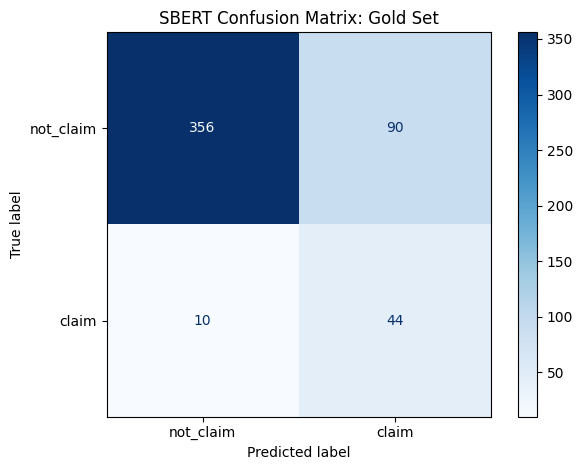

In [16]:
# Confusion matrix for SBERT
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_gold, clf_sbert.predict(X_gold_sbert))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not_claim", "claim"])
disp.plot(cmap="Blues")
plt.title("SBERT Confusion Matrix: Gold Set")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation (SBERT, Gold Set)

- **True Negatives: 356** not_claim posts correctly identified
- **False Positives: 90** not_claim posts incorrectly predicted as claims
- **False Negatives: 10** claim posts missed by the model
- **True Positives: 44** claim posts correctly identified

The model misses relatively few real claims (10 false negatives) while producing a moderate number
of false positives (90). This asymmetry is intentional given the class weighting strategy and is
appropriate for a weak supervision pipeline where recall is prioritised.

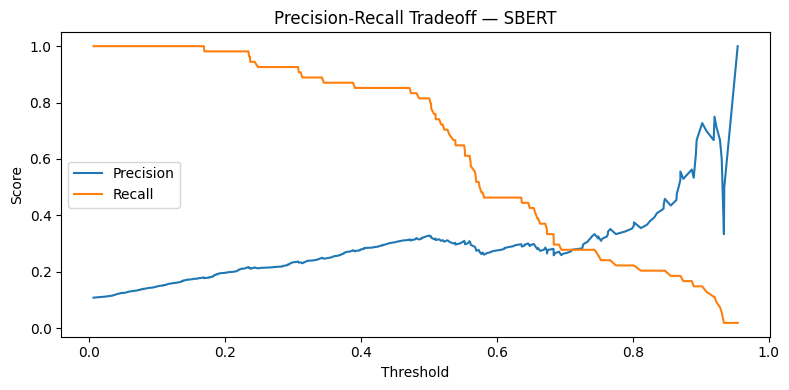

Best threshold: 0.50
Best MCC: 0.430


In [17]:
# Threshold analysis for SBERT
from sklearn.metrics import precision_recall_curve
import numpy as np

probs = clf_sbert.predict_proba(X_gold_sbert)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_gold, probs)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff — SBERT")
plt.legend()
plt.tight_layout()
plt.show()

# Find threshold that maximises MCC
mccs = []
for t in thresholds:
    preds = (probs >= t).astype(int)
    mccs.append(matthews_corrcoef(y_gold, preds))

best_idx = np.argmax(mccs)
print(f"Best threshold: {thresholds[best_idx]:.2f}")
print(f"Best MCC: {mccs[best_idx]:.3f}")

In [15]:
df_check = pd.read_csv("/content/drive/MyDrive/ads/posts_sample.csv")
print(f"Rows: {len(df_check)}")
print(f"Columns: {df_check.columns.tolist()}")
print(f"\nEngagement stats:")
combined = df_check["like_count"] + df_check["repost_count"]
print(combined.describe())
print(f"\nRows with zero engagement: {(combined == 0).sum()}")
print(f"Rows with text_length <= 30: {(df_check['text_length'] <= 30).sum()}")

Rows: 100000
Columns: ['post_id', 'user_id', 'text', 'date', 'like_count', 'reply_count', 'repost_count', 'is_reply', 'is_repost', 'is_quote', 'sent_label', 'sent_score', 'timestamp', 'text_length']

Engagement stats:
count    100000.000000
mean        247.262600
std        1440.954506
min           0.000000
25%           0.000000
50%           2.000000
75%          10.000000
max       30416.000000
dtype: float64

Rows with zero engagement: 29345
Rows with text_length <= 30: 27559


In [18]:
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# Load full 100k sample
df_full = pd.read_csv("/content/drive/MyDrive/ads/posts_sample.csv")
df_full["text"] = df_full["text"].fillna("")

# Apply same filters as training data
df_full["combined_engagement"] = df_full["like_count"] + df_full["repost_count"]
df_full = df_full[
    (df_full["text_length"] > 30) &
    (df_full["combined_engagement"] > 0)
].copy().reset_index(drop=True)

threshold = df_full["combined_engagement"].quantile(0.9)
df_full["is_viral"] = (df_full["combined_engagement"] >= threshold).astype(int)

print(f"Filtered sample: {len(df_full):,} rows")
print(f"Viral threshold: {threshold}, viral rate: {df_full['is_viral'].mean()*100:.1f}%")

Filtered sample: 51,773 rows
Viral threshold: 677.0, viral rate: 10.0%


In [19]:
# Verification checks before encoding
print(f"Rows: {len(df_full):,}")
print(f"Columns: {df_full.columns.tolist()}")
print(f"is_viral present: {'is_viral' in df_full.columns}")
print(f"combined_engagement present: {'combined_engagement' in df_full.columns}")
print(f"Viral rate: {df_full['is_viral'].mean()*100:.1f}%")
print(f"Zero engagement rows: {(df_full['combined_engagement'] == 0).sum()}")
print(f"Short text rows: {(df_full['text_length'] <= 30).sum()}")
print(f"Null text rows: {df_full['text'].isna().sum()}")
print(f"Viral threshold check: {df_full['combined_engagement'].quantile(0.9)}")

Rows: 51,773
Columns: ['post_id', 'user_id', 'text', 'date', 'like_count', 'reply_count', 'repost_count', 'is_reply', 'is_repost', 'is_quote', 'sent_label', 'sent_score', 'timestamp', 'text_length', 'combined_engagement', 'is_viral']
is_viral present: True
combined_engagement present: True
Viral rate: 10.0%
Zero engagement rows: 0
Short text rows: 0
Null text rows: 0
Viral threshold check: 677.0


In [20]:
# Encode the sample with SBERT
print("\nEncoding full sample with SBERT...")
X_full_sbert = sbert.encode(
    df_full["text"].tolist(),
    show_progress_bar=True,
    batch_size=64
)

# Predict using best model (SBERT, threshold 0.50)
df_full["claim_probability"] = clf_sbert.predict_proba(X_full_sbert)[:, 1]
df_full["is_claim_pred"]     = (df_full["claim_probability"] >= 0.50).astype(int)

print(f"\nPredicted claims:     {df_full['is_claim_pred'].sum():,}")
print(f"Predicted not_claims: {(df_full['is_claim_pred'] == 0).sum():,}")
print(f"Claim rate:           {df_full['is_claim_pred'].mean()*100:.1f}%")


Encoding full sample with SBERT...


Batches:   0%|          | 0/809 [00:00<?, ?it/s]


Predicted claims:     12,674
Predicted not_claims: 39,099
Claim rate:           24.5%



 Viral rate by predicted claim
is_claim_pred
not_claim    0.077572
claim        0.169639
Name: is_viral, dtype: float64

 Median combined engagement by predicted claim
is_claim_pred
not_claim    4.0
claim        9.0
Name: combined_engagement, dtype: float64

 Mean combined engagement by predicted claim
is_claim_pred
not_claim    318.693061
claim        746.511835
Name: combined_engagement, dtype: float64

 Mann-Whitney U test
Statistic: 288147554
P-value:   0.0000
Significant (p < 0.05)


/tmp/ipykernel_6565/435338328.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


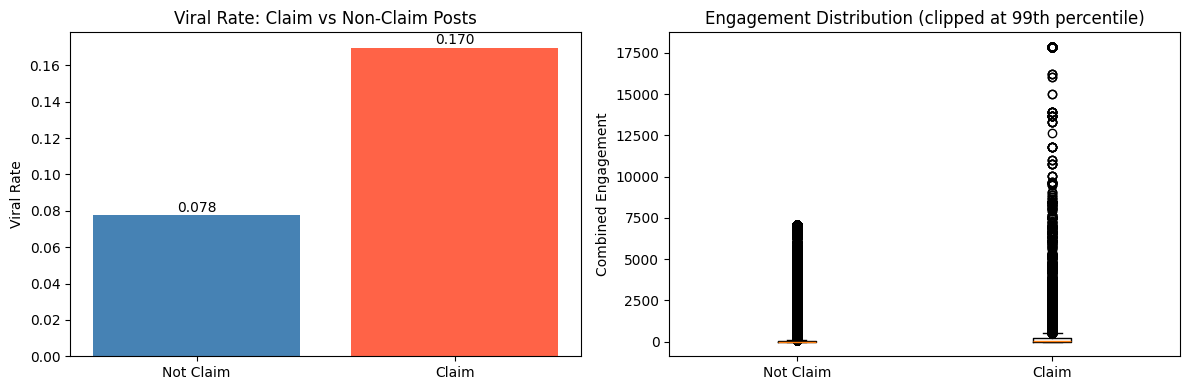


Saved to posts_sample_with_claims.csv


In [25]:
# Virality analysis

print("\n Viral rate by predicted claim")
viral_rates = df_full.groupby("is_claim_pred")["is_viral"].mean()
print(viral_rates.rename({0: "not_claim", 1: "claim"}))

print("\n Median combined engagement by predicted claim")
print(df_full.groupby("is_claim_pred")["combined_engagement"].median()
      .rename({0: "not_claim", 1: "claim"}))

print("\n Mean combined engagement by predicted claim")
print(df_full.groupby("is_claim_pred")["combined_engagement"].mean()
      .rename({0: "not_claim", 1: "claim"}))

# Statistical test
from scipy.stats import mannwhitneyu
claim_eng    = df_full[df_full["is_claim_pred"] == 1]["combined_engagement"]
nonclaim_eng = df_full[df_full["is_claim_pred"] == 0]["combined_engagement"]
stat, p = mannwhitneyu(claim_eng, nonclaim_eng, alternative="two-sided")
print(f"\n Mann-Whitney U test")
print(f"Statistic: {stat:.0f}")
print(f"P-value:   {p:.4f}")
print("Significant (p < 0.05)" if p < 0.05 else "Not significant (p >= 0.05)")

# Plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Not Claim", "Claim"],
            [viral_rates[0], viral_rates[1]],
            color=["steelblue", "tomato"])
axes[0].set_ylabel("Viral Rate")
axes[0].set_title("Viral Rate: Claim vs Non-Claim Posts")
for i, v in enumerate([viral_rates[0], viral_rates[1]]):
    axes[0].text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=10)

axes[1].boxplot(
    [nonclaim_eng.clip(upper=nonclaim_eng.quantile(0.99)),
     claim_eng.clip(upper=claim_eng.quantile(0.99))],
    labels=["Not Claim", "Claim"]
)
axes[1].set_ylabel("Combined Engagement")
axes[1].set_title("Engagement Distribution (clipped at 99th percentile)")

plt.tight_layout()
plt.show()

# Save
df_full.to_csv("/content/drive/MyDrive/ads/posts_sample_with_claims.csv", index=False)
print("\nSaved to posts_sample_with_claims.csv")

### Virality Analysis

The SBERT classifier was applied to a filtered corpus of 51,773 Bluesky posts (filtered to
text_length > 30 and combined_engagement > 0, consistent with training data preparation).
The virality threshold was defined as the 90th percentile of combined engagement (likes + reposts),
yielding a threshold of 677 and a viral rate of 10.0%.

**Key findings (not claim vs claim)**

- Viral rate: 0.078 vs 0.170
- Median engagement: 4.0 vs 9.0
- Mean engagement: 318.7 vs 746.5

Posts predicted as containing verifiable factual claims showed a **118% higher viral rate** and more than double the mean engagement compared to non-claim posts.

A Mann-Whitney U test confirmed this difference is statistically significant
(U = 288,147,554, p < 0.0001).

**Limitations:** The classifier's precision of 0.33 means approximately two thirds of predicted
claims may be false positives. A qualitativem, manual review of 50 predicted claim posts confirmed that
genuine claim-making posts (news reports, scientific findings, policy statements) were present
alongside false positives including non-English posts and high-engagement personal updates.
The virality finding should therefore be interpreted as exploratory and correlational rather than
causal. Future work with higher-precision labelling would strengthen this finding.

# Why This Result is Significant

Despite a precision of 0.33, the virality finding remains interpretable for three reasons. First, the SBERT classifier achieves MCC = 0.430 on the held-out gold set, confirming it has genuine discriminative ability beyond random guessing. Second, false positives in a weak classifier are unlikely to be systematically biased toward viral content, meaning they dilute rather than amplify the observed engagement difference. The true signal between genuine claim posts and non-claim posts is therefore likely stronger than reported. Third, the Mann-Whitney U test (U = 288,147,554, p < 0.0001) is non-parametric and rank-based, making it robust to distributional noise introduced by classifier imprecision. The p-value, which is < 0.0001, on 51,773 observations means the probability of observing this large a difference by chance is essentially zero. The finding should be interpreted as exploratory evidence that claim-like content is associated with higher virality on Bluesky, rather than a causal claim.